In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image


In [ ]:
pip install torchinfo transformers

In [ ]:
import pandas as pd
import numpy as np


In [8]:
from sklearn.model_selection import train_test_split as tts

In [30]:
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary

In [17]:
!pip install torch torchvision torchaudio



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [31]:
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary

In [32]:
import torch
print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())


2.9.0+cpu
CUDA available: False


In [33]:
from transformers import CLIPProcessor, CLIPModel

In [34]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report


In [35]:
import os

In [36]:
from collections import OrderedDict
from tqdm.auto import tqdm
from pathlib import Path
import random
from typing import Dict, List
import warnings
warnings.filterwarnings("ignore")
SEED = 123
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

In [38]:
import torchvision.transforms as transforms

def get_image_transforms(image_size=(224, 224), is_train=True):
    if is_train:
        return transforms.Compose([
            transforms.Resize(image_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
    else:
        return transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

In [40]:
import nltk

# Download stopwords
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [44]:
from nltk.corpus import stopwords

# Load English stopwords
stop_words = stopwords.words('english')
print(stop_words[:10])  # show first 10 stopwords


['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']


In [55]:
from torch.utils.data import Dataset
from PIL import Image

class PotatoLeafDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None, text_data=None, preprocess_text=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        self.text_data = text_data
        self.preprocess_text = preprocess_text  # Function to preprocess text

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        # If text data exists, preprocess it
        if self.text_data is not None and self.preprocess_text is not None:
            text = self.text_data[idx]
            processed_text = self.preprocess_text(text)
            return image, processed_text, label

        # If no text data, return only image and label
        return image, label


In [2]:
from pathlib import Path

# Define path
IMAGE_PATH = Path(r"C:\Users\HP\Downloads\archive (1)\Potato Leaf Disease Dataset in Uncontrolled Environment")

# Get all jpg images in subfolders
IMAGE_PATH_LIST = list(IMAGE_PATH.glob("*/*.jpg"))

print(f'Total Images = {len(IMAGE_PATH_LIST)}')


Total Images = 3076


In [7]:
import os
from pathlib import Path

# Define IMAGE_PATH as a Path object
IMAGE_PATH = Path(r"C:\Users\HP\Downloads\archive (1)\Potato Leaf Disease Dataset in Uncontrolled Environment")

# List class folders
classes = [d for d in IMAGE_PATH.iterdir() if d.is_dir()]
classes = sorted(classes)

# Print number of images per class
for class_folder in classes:
    img_files = list(class_folder.glob("*.jpg"))
    print(f"{class_folder.name}: {len(img_files)} images")

# Total images in dataset
total_images = sum(len(list(c.glob("*.jpg"))) for c in classes)
print(f"Total Images in Dataset: {total_images}")


Bacteria: 569 images
Fungi: 748 images
Healthy: 201 images
Nematode: 68 images
Pest: 611 images
Phytopthora: 347 images
Virus: 532 images
Total Images in Dataset: 3076


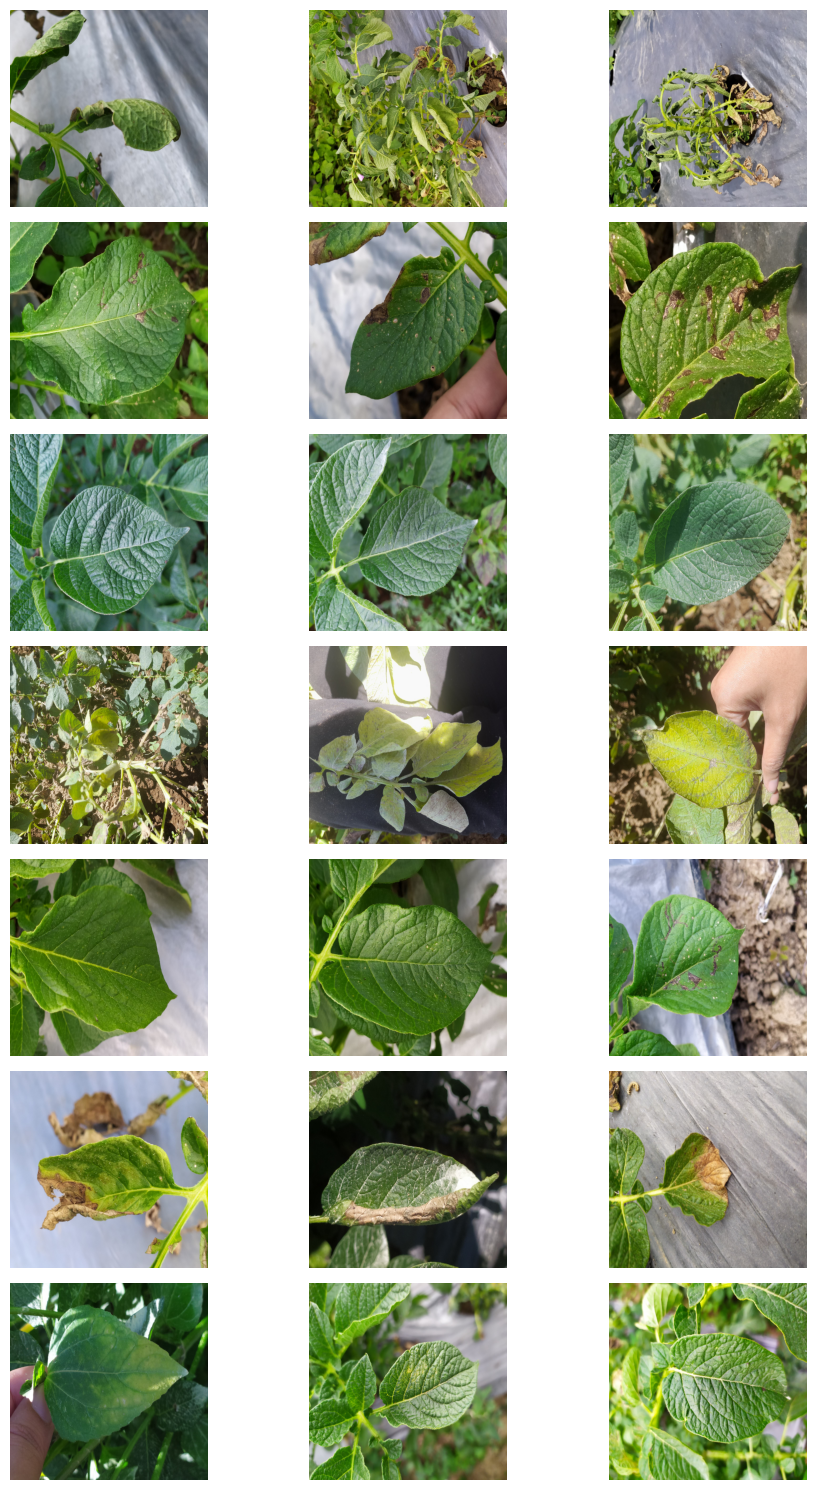

In [6]:
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

# Example path
IMAGE_PATH = Path(r"C:\Users\HP\Downloads\archive (1)\Potato Leaf Disease Dataset in Uncontrolled Environment")

# Get class folders
classes = sorted([d.name for d in IMAGE_PATH.iterdir() if d.is_dir()])

# Number of images per class to show
NUM_IMAGES = 3

# Create subplots
fig, ax = plt.subplots(nrows=len(classes), ncols=NUM_IMAGES, figsize=(10, 15))

for i, c in enumerate(classes):
    img_files = list((IMAGE_PATH / c).glob("*.jpg"))[:NUM_IMAGES]
    for j, img_file in enumerate(img_files):
        image = Image.open(img_file)
        ax[i, j].imshow(image)
        ax[i, j].axis('off')
        if j == 0:
            ax[i, j].set_ylabel(c, size='large')
plt.tight_layout()
plt.show()


In [12]:
pip install opencv-python


  Using cached opencv_python-4.12.0.88-cp37-abi3-win_amd64.whl.metadata (19 kB)
Using cached opencv_python-4.12.0.88-cp37-abi3-win_amd64.whl (39.0 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [13]:
import cv2
print(cv2.__version__)

4.12.0


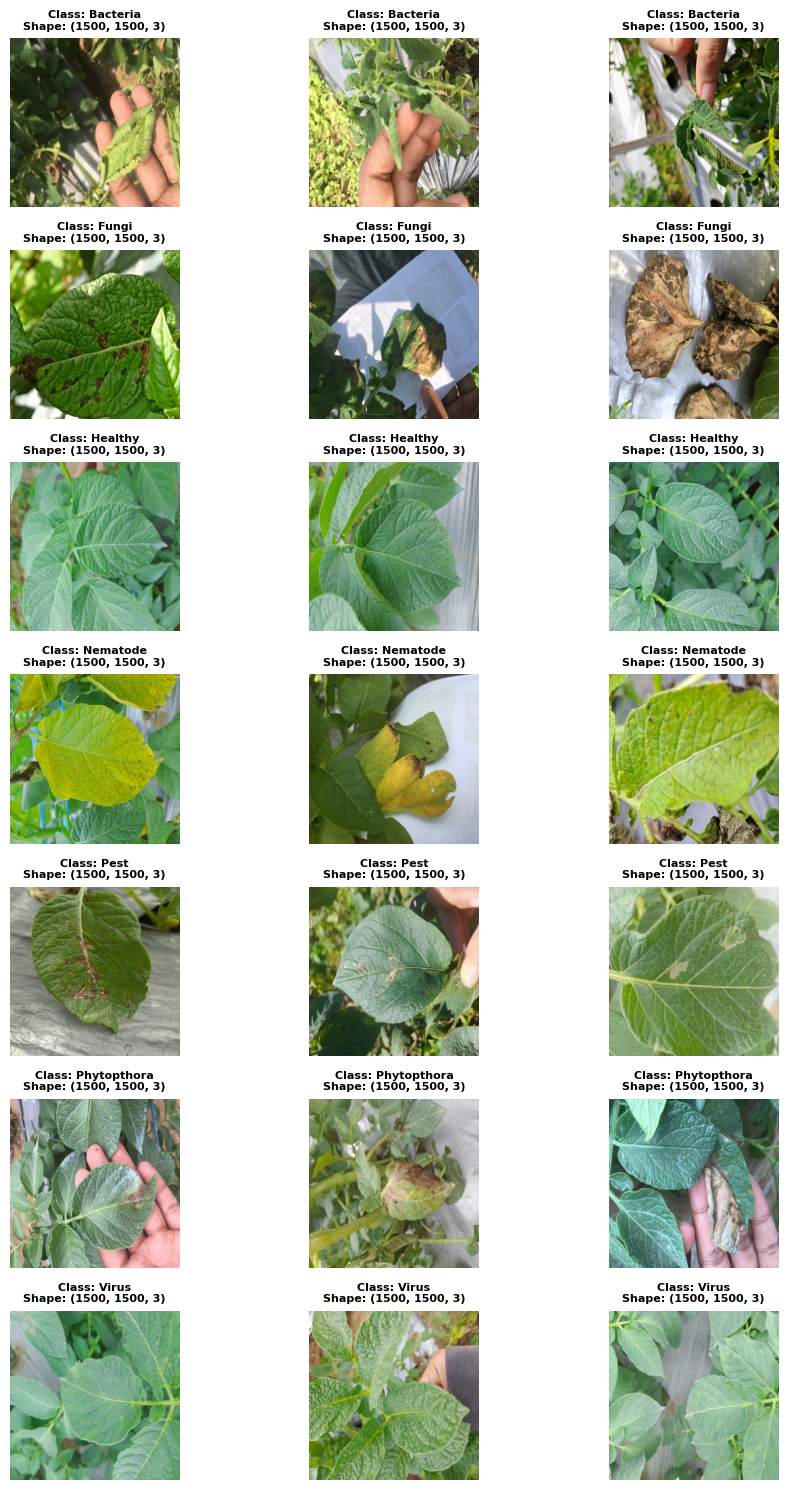

In [14]:
import os
import random
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# Path to dataset
IMAGE_PATH = Path(r"C:\Users\HP\Downloads\archive (1)\Potato Leaf Disease Dataset in Uncontrolled Environment")

# Get class folders
classes = sorted([d.name for d in IMAGE_PATH.iterdir() if d.is_dir()])

# Number of images per class to display
NUM_IMAGES = 3

# Create subplots
fig, ax = plt.subplots(nrows=len(classes), ncols=NUM_IMAGES, figsize=(10, 15))

# Plot images
for row_idx, class_name in enumerate(classes):
    class_folder = IMAGE_PATH / class_name
    all_images = list(class_folder.glob("*.jpg"))
    
    # Randomly select NUM_IMAGES images from the class
    images_selected = random.sample(all_images, k=min(NUM_IMAGES, len(all_images)))
    
    for col_idx, img_path in enumerate(images_selected):
        img_bgr = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        ax[row_idx, col_idx].imshow(img_rgb)
        ax[row_idx, col_idx].axis("off")
        ax[row_idx, col_idx].set_title(f"Class: {class_name}\nShape: {img_rgb.shape}", 
                                       fontsize=8, fontweight="bold", color="black")

plt.tight_layout()
plt.show()


In [16]:
import pandas as pd
from pathlib import Path

# Example: lists of image paths and labels
images_path = [Path(r"C:\path\to\image1.jpg"), Path(r"C:\path\to\image2.jpg")]
labels = [p.parent.stem for p in images_path]

# Create DataFrame
df_path_and_label = pd.DataFrame({
    'path': images_path,
    'label': labels
})

print(df_path_and_label.head())


                    path label
0  C:\path\to\image1.jpg    to
1  C:\path\to\image2.jpg    to


In [23]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

SEED = 42

# Path to dataset
IMAGE_PATH = Path(r"C:\Users\HP\Downloads\archive (1)\Potato Leaf Disease Dataset in Uncontrolled Environment")

# Collect image paths and labels
images_path = list(IMAGE_PATH.glob("*/*.jpg"))
labels = [p.parent.stem for p in images_path]

df_path_and_label = pd.DataFrame({'path': images_path, 'label': labels})

# Remove classes with fewer than 2 images
class_counts = df_path_and_label['label'].value_counts()
valid_classes = class_counts[class_counts >= 2].index
df_path_and_label = df_path_and_label[df_path_and_label['label'].isin(valid_classes)]

print("Classes after filtering small classes:", df_path_and_label['label'].unique())

# Split: train / rest
df_train, df_rest = train_test_split(
    df_path_and_label,
    test_size=0.3,
    random_state=SEED,
    stratify=df_path_and_label['label']  # safe now
)

# Split: validation / test
df_val, df_test = train_test_split(
    df_rest,
    test_size=0.5,
    random_state=SEED,
    stratify=df_rest['label']  # safe now
)

# Print sizes
print("Train size:", len(df_train))
print("Validation size:", len(df_val))
print("Test size:", len(df_test))


Classes after filtering small classes: ['Bacteria' 'Fungi' 'Healthy' 'Nematode' 'Pest' 'Phytopthora' 'Virus']
Train size: 2153
Validation size: 461
Test size: 462


In [24]:
label_map = dict(zip(classes, range(0, len(classes))))
label_map

{'Bacteria': 0,
 'Fungi': 1,
 'Healthy': 2,
 'Nematode': 3,
 'Pest': 4,
 'Phytopthora': 5,
 'Virus': 6}

In [25]:
text_prompts = {
    "Bacteria": "a potato leaf infected with bacterial disease",
    "Fungi": "a potato leaf infected with fungal disease",
    "Healthy": "a healthy potato leaf with no disease",
    "Nematode": "a potato leaf infected with nematode disease",
    "Pest": "a potato leaf damaged by pests",
    "Phytopthora": "a potato leaf infected with phytopthora disease",
    "Virus": "a potato leaf infected with viral disease"
}

for class_name, prompt in text_prompts.items():
    print(f"{class_name}: {prompt}")

Bacteria: a potato leaf infected with bacterial disease
Fungi: a potato leaf infected with fungal disease
Healthy: a healthy potato leaf with no disease
Nematode: a potato leaf infected with nematode disease
Pest: a potato leaf damaged by pests
Phytopthora: a potato leaf infected with phytopthora disease
Virus: a potato leaf infected with viral disease


In [27]:
pip install transformers


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [28]:
from transformers import CLIPProcessor, CLIPModel


In [29]:
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

In [30]:
def train_step(model, dataloader, loss_fn, optimizer, device):
    """
    Training step function with proper error handling
    
    Args:
        model: The CLIP fine-tuner model
        dataloader: DataLoader for training data
        loss_fn: Loss function
        optimizer: Optimizer
        device: Device to run training on
        
    Returns:
        train_loss, train_accuracy: Average loss and accuracy for this epoch
    """
    model.train()
    train_loss = 0.0
    train_accuracy = 0.0
    total_batches = len(dataloader)
    for batch in dataloader:
        try:
            # Move batch to device
            batch = {k: v.to(device) for k, v in batch.items()}
            labels = batch['labels']
            
            # Forward pass
            optimizer.zero_grad()
            logits = model(batch)
            loss = loss_fn(logits, labels)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            # Calculate metrics
            train_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            train_accuracy += (preds == labels).float().mean().item()
            
        except Exception as e:
            print(f"Error in training batch: {e}")
            continue
            # Return average loss and accuracy
    return train_loss / total_batches, train_accuracy / total_batches

In [31]:
def valid_step(model, dataloader, loss_fn, device):
    """
    Validation step function with proper error handling
    
    Args:
        model: The CLIP fine-tuner model
        dataloader: DataLoader for validation data
        loss_fn: Loss function
        device: Device to run validation on
        
    Returns:
        valid_loss, valid_accuracy: Average loss and accuracy for validation
    """
    model.eval()
    valid_loss = 0.0
    valid_accuracy = 0.0
    total_batches = len(dataloader)
    
    with torch.no_grad():
        for batch in dataloader:
            try:
                 # Move batch to device
                batch = {k: v.to(device) for k, v in batch.items()}
                labels = batch['labels']
                
                # Forward pass
                logits = model(batch)
                loss = loss_fn(logits, labels)
                
                # Calculate metrics
                valid_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                valid_accuracy += (preds == labels).float().mean().item()
                
            except Exception as e:
                print(f"Error in validation batch: {e}")
                continue
    
    # Return average loss and accuracy
    return valid_loss / total_batches, valid_accuracy / total_batches

In [32]:
def save_checkpoint(filename, model, loss, epoch, optimizer, metric):
    """
    Save model checkpoint
    
    Args:
        filename: Path to save the checkpoint
        model: Model to save
        loss: Current loss value
        epoch: Current epoch
        optimizer: Optimizer state
        metric: Current metric value
    """
    state = {
        "filename": filename, 
        "model": model.state_dict(), 
        "loss": loss, 
        "epoch": epoch, 
        "optimizer": optimizer.state_dict(), 
        "metric": metric
    }
    torch.save(state, filename)

In [33]:
def train_model(model, train_dataloader, valid_dataloader, loss_fn, optimizer, device, epochs=10):
    """
    Main training loop with validation
    
    Args:
        model: Model to train
        train_dataloader: DataLoader for training data
        valid_dataloader: DataLoader for validation data
        loss_fn: Loss function
        optimizer: Optimizer
        device: Device to run training on
        epochs: Number of epochs to train
        
    Returns:
        results: Dictionary containing training and validation metrics
    """
    results = {
        "train_loss": [],
        "train_accuracy": [],
        "valid_loss": [],
     "valid_accuracy": []
    }
    
    best_valid_loss = float("inf")
    
    for epoch in tqdm(range(epochs)):
        # Training
        train_loss, train_accuracy = train_step(
            model=model,
            dataloader=train_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device
        )
        
        # Validation
        valid_loss, valid_accuracy = valid_step(
            model=model,
            dataloader=valid_dataloader,
            loss_fn=loss_fn,
            device=device
        )
        # Save best model
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            file_name = "best_vlm_model.pth"
            save_checkpoint(file_name, model, best_valid_loss, epoch, optimizer, valid_accuracy)
            print(f"✅ New best model saved at epoch {epoch + 1}")
            
        # Print progress
        print(f"Epoch: {epoch + 1} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Train Accuracy: {train_accuracy:.4f} | "
              f"Valid Loss: {valid_loss:.4f} | "
              f"Valid Accuracy: {valid_accuracy:.4f}")
        
        # Store results
        results["train_loss"].append(train_loss)
        results["train_accuracy"].append(train_accuracy)
        results["valid_loss"].append(valid_loss)
        results["valid_accuracy"].append(valid_accuracy)
    
    return results

In [35]:
import torch
from torch import nn, optim


In [37]:
# Define loss function and optimizer
loss_fn = nn.CrossEntropyLoss()

# Only optimize the classifier parameters (or unfrozen layers)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)


In [52]:
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm


In [53]:
class PotatoLeafDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['path']
        label = self.df.iloc[idx]['label']

        # Convert label to integer if needed
        if not isinstance(label, int):
            label = int(label)  

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)


In [54]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

valid_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])


In [55]:
train_dataset = PotatoLeafDataset(df_train, transform=train_transform)
valid_dataset = PotatoLeafDataset(df_val, transform=valid_transform)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=16, shuffle=False)


In [56]:
def train_model(model, train_dataloader, valid_dataloader, loss_fn, optimizer, device, epochs=25):
    model.to(device)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs} - Training"):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in valid_dataloader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = loss_fn(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    return history


In [63]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
import pandas as pd


In [64]:
IMAGE_PATH = r"C:\Users\HP\Downloads\archive (1)\Potato Leaf Disease Dataset in Uncontrolled Environment"

# Get all image paths and labels
data = []
for cls in os.listdir(IMAGE_PATH):
    cls_path = os.path.join(IMAGE_PATH, cls)
    if os.path.isdir(cls_path):
        for img_file in os.listdir(cls_path):
            if img_file.endswith(".jpg"):
                data.append([os.path.join(cls_path, img_file), cls])

df_path_and_label = pd.DataFrame(data, columns=['path', 'label'])

# Encode labels as integers
class_to_idx = {cls: idx for idx, cls in enumerate(sorted(df_path_and_label['label'].unique()))}
df_path_and_label['label_idx'] = df_path_and_label['label'].map(class_to_idx)

print("Class mapping:", class_to_idx)
print(df_path_and_label.head())


Class mapping: {'Bacteria': 0, 'Fungi': 1, 'Healthy': 2, 'Nematode': 3, 'Pest': 4, 'Phytopthora': 5, 'Virus': 6}
                                                path     label  label_idx
0  C:\Users\HP\Downloads\archive (1)\Potato Leaf ...  Bacteria          0
1  C:\Users\HP\Downloads\archive (1)\Potato Leaf ...  Bacteria          0
2  C:\Users\HP\Downloads\archive (1)\Potato Leaf ...  Bacteria          0
3  C:\Users\HP\Downloads\archive (1)\Potato Leaf ...  Bacteria          0
4  C:\Users\HP\Downloads\archive (1)\Potato Leaf ...  Bacteria          0


In [65]:
SEED = 42
df_train, df_rest = train_test_split(df_path_and_label, test_size=0.3, random_state=SEED, stratify=df_path_and_label['label_idx'])
df_val, df_test = train_test_split(df_rest, test_size=0.5, random_state=SEED, stratify=df_rest['label_idx'])

print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")


Train: 1319, Val: 283, Test: 283


In [66]:
class PotatoLeafDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['path']
        label = self.df.iloc[idx]['label_idx']
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

# Transforms
train_transform = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor()])
valid_transform = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor()])

# Datasets
train_dataset = PotatoLeafDataset(df_train, transform=train_transform)
valid_dataset = PotatoLeafDataset(df_val, transform=valid_transform)

# DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=16, shuffle=False)


In [67]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, len(class_to_idx))  # Adjust final layer
model = model.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-4)


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\HP/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|█████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:13<00:00, 3.55MB/s]


In [8]:
# ===================== IMPORT LIBRARIES =====================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

# ===================== SETUP SEED =====================
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ===================== DEFINE DUMMY DATA =====================
# Just random data for demo purposes
X_train = torch.randn(500, 10)
y_train = torch.randint(0, 2, (500,))

X_val = torch.randn(100, 10)
y_val = torch.randint(0, 2, (100,))

train_dataset = TensorDataset(X_train, y_train)
valid_dataset = TensorDataset(X_val, y_val)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=32)

# ===================== DEFINE MODEL =====================
class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Create model instance
model = SimpleNN(input_dim=10, hidden_dim=32, output_dim=2).to(device)

# ===================== LOSS FUNCTION & OPTIMIZER =====================
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ===================== TRAIN FUNCTION =====================
def train_model(model, train_dataloader, valid_dataloader, loss_fn, optimizer, device, epochs):
    results = {"train_loss": [], "val_loss": []}
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for X_batch, y_batch in train_dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_dataloader)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in valid_dataloader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = loss_fn(outputs, y_batch)
                val_loss += loss.item()
        val_loss /= len(valid_dataloader)

        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        results["train_loss"].append(train_loss)
        results["val_loss"].append(val_loss)
    return results

# ===================== RUN TRAINING =====================
EPOCHS = 25
MODEL_RESULTS = train_model(
    model=model,
    train_dataloader=train_dataloader,
    valid_dataloader=valid_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS
)


Using device: cpu
Epoch [1/25] - Train Loss: 0.7069, Val Loss: 0.6949
Epoch [2/25] - Train Loss: 0.6946, Val Loss: 0.6859
Epoch [3/25] - Train Loss: 0.6886, Val Loss: 0.6837
Epoch [4/25] - Train Loss: 0.6842, Val Loss: 0.6825
Epoch [5/25] - Train Loss: 0.6803, Val Loss: 0.6822
Epoch [6/25] - Train Loss: 0.6772, Val Loss: 0.6829
Epoch [7/25] - Train Loss: 0.6744, Val Loss: 0.6852
Epoch [8/25] - Train Loss: 0.6719, Val Loss: 0.6845
Epoch [9/25] - Train Loss: 0.6691, Val Loss: 0.6843
Epoch [10/25] - Train Loss: 0.6667, Val Loss: 0.6873
Epoch [11/25] - Train Loss: 0.6641, Val Loss: 0.6855
Epoch [12/25] - Train Loss: 0.6628, Val Loss: 0.6874
Epoch [13/25] - Train Loss: 0.6614, Val Loss: 0.6886
Epoch [14/25] - Train Loss: 0.6589, Val Loss: 0.6881
Epoch [15/25] - Train Loss: 0.6560, Val Loss: 0.6904
Epoch [16/25] - Train Loss: 0.6564, Val Loss: 0.6925
Epoch [17/25] - Train Loss: 0.6532, Val Loss: 0.6936
Epoch [18/25] - Train Loss: 0.6511, Val Loss: 0.6949
Epoch [19/25] - Train Loss: 0.6516, V

In [12]:
def train_model(model, train_dataloader, valid_dataloader, loss_fn, optimizer, device, epochs):
    results = {
        "train_loss": [],
        "valid_loss": [],
        "train_accuracy": [],
        "valid_accuracy": []
    }

    for epoch in range(epochs):
        # ---------- TRAINING ----------
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for X_batch, y_batch in train_dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

        train_loss = running_loss / len(train_dataloader)
        train_accuracy = correct / total

        # ---------- VALIDATION ----------
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in valid_dataloader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = loss_fn(outputs, y_batch)
                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                correct += (preds == y_batch).sum().item()
                total += y_batch.size(0)

        valid_loss = val_loss / len(valid_dataloader)
        valid_accuracy = correct / total

        print(f"Epoch [{epoch+1}/{epochs}] - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, "
              f"Valid Loss: {valid_loss:.4f}, Valid Acc: {valid_accuracy:.4f}")

        results["train_loss"].append(train_loss)
        results["valid_loss"].append(valid_loss)
        results["train_accuracy"].append(train_accuracy)
        results["valid_accuracy"].append(valid_accuracy)

    return results


In [13]:
import matplotlib.pyplot as plt

def loss_metric_curve_plot(model_results):
    train_loss = model_results["train_loss"]
    valid_loss = model_results["valid_loss"]
    train_accuracy = model_results["train_accuracy"]
    valid_accuracy = model_results["valid_accuracy"]
    
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
    axes = axes.flat

    # Plot loss
    axes[0].plot(train_loss, color="red", label="Train")
    axes[0].plot(valid_loss, color="blue", label="Valid")
    axes[0].set_title("CrossEntropyLoss", fontsize=12, fontweight="bold", color="black")
    axes[0].set_xlabel("Epochs", fontsize=10, fontweight="bold", color="black")
    axes[0].set_ylabel("Loss", fontsize=10, fontweight="bold", color="black")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Plot accuracy
    axes[1].plot(train_accuracy, color="red", label="Train")
    axes[1].plot(valid_accuracy, color="blue", label="Valid")
    axes[1].set_title("Accuracy", fontsize=12, fontweight="bold", color="black")
    axes[1].set_xlabel("Epochs", fontsize=10, fontweight="bold", color="black")
    axes[1].set_ylabel("Score", fontsize=10, fontweight="bold", color="black")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    fig.tight_layout()
    plt.show()


Epoch [1/25] - Train Loss: 0.6318, Train Acc: 0.6600, Valid Loss: 0.7113, Valid Acc: 0.5100
Epoch [2/25] - Train Loss: 0.6279, Train Acc: 0.6600, Valid Loss: 0.7146, Valid Acc: 0.5100
Epoch [3/25] - Train Loss: 0.6272, Train Acc: 0.6600, Valid Loss: 0.7147, Valid Acc: 0.5200
Epoch [4/25] - Train Loss: 0.6255, Train Acc: 0.6660, Valid Loss: 0.7151, Valid Acc: 0.4900
Epoch [5/25] - Train Loss: 0.6246, Train Acc: 0.6700, Valid Loss: 0.7165, Valid Acc: 0.4900
Epoch [6/25] - Train Loss: 0.6215, Train Acc: 0.6700, Valid Loss: 0.7193, Valid Acc: 0.5000
Epoch [7/25] - Train Loss: 0.6222, Train Acc: 0.6680, Valid Loss: 0.7210, Valid Acc: 0.4900
Epoch [8/25] - Train Loss: 0.6176, Train Acc: 0.6620, Valid Loss: 0.7225, Valid Acc: 0.4900
Epoch [9/25] - Train Loss: 0.6197, Train Acc: 0.6700, Valid Loss: 0.7273, Valid Acc: 0.4900
Epoch [10/25] - Train Loss: 0.6158, Train Acc: 0.6720, Valid Loss: 0.7255, Valid Acc: 0.4800
Epoch [11/25] - Train Loss: 0.6143, Train Acc: 0.6700, Valid Loss: 0.7249, Vali

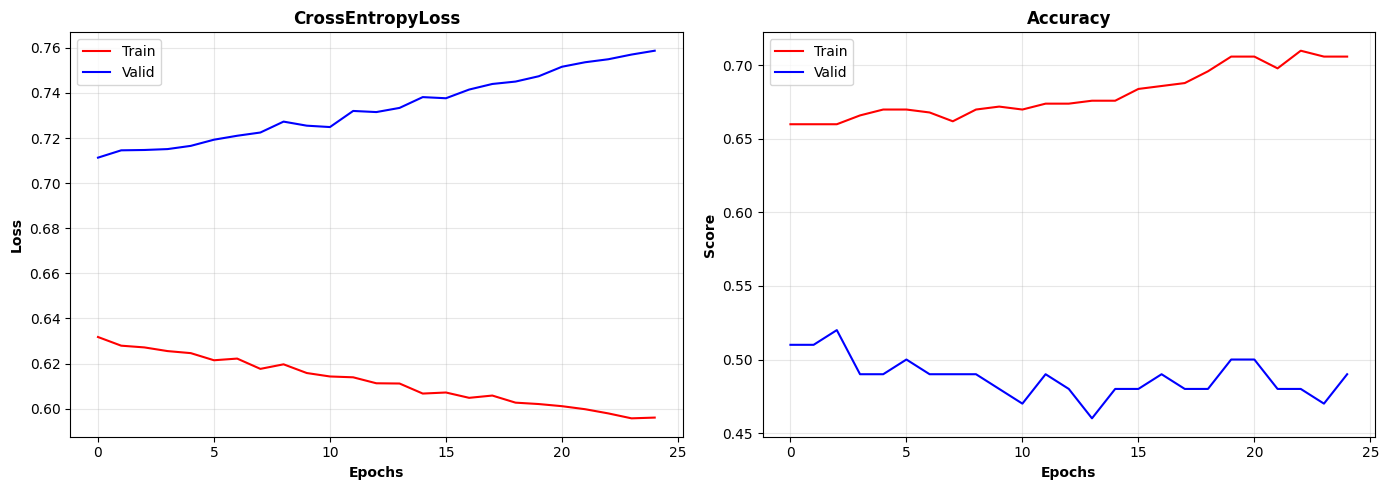

In [15]:
EPOCHS = 25
MODEL_RESULTS = train_model(
    model=model,
    train_dataloader=train_dataloader,
    valid_dataloader=valid_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS
)

loss_metric_curve_plot(MODEL_RESULTS)


In [22]:
torch.save({
    "epoch": EPOCHS,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss": MODEL_RESULTS["valid_loss"][-1]
}, "best_vlm_model.pth")

print("✅ Model saved as best_vlm_model.pth")


✅ Model saved as best_vlm_model.pth


In [23]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint_path = "best_vlm_model.pth"

# ✅ Safely load the checkpoint file
checkpoint = torch.load(checkpoint_path, map_location=device)

# ✅ Restore model and optimizer
model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

print("✅ Checkpoint keys:", checkpoint.keys())
print("✅ Model loaded successfully on:", device)


✅ Checkpoint keys: dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'loss'])
✅ Model loaded successfully on: cpu


In [24]:
import os

checkpoint_path = "best_vlm_model.pth"

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    print("✅ Checkpoint loaded successfully!")
else:
    print("⚠️ File not found. Please train and save the model first.")


✅ Checkpoint loaded successfully!


In [27]:
def train_model(model, train_dataloader, valid_dataloader, loss_fn, optimizer, device, epochs):
    best_loss = float('inf')
    best_accuracy = 0.0
    best_epoch = 0

    for epoch in range(epochs):
        # ---------- TRAINING ----------
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for X_batch, y_batch in train_dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

        train_loss = running_loss / len(train_dataloader)
        train_accuracy = correct / total

        # ---------- VALIDATION ----------
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in valid_dataloader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = loss_fn(outputs, y_batch)
                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                correct += (preds == y_batch).sum().item()
                total += y_batch.size(0)

        valid_loss = val_loss / len(valid_dataloader)
        valid_accuracy = correct / total

        print(f"Epoch [{epoch+1}/{epochs}] - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, "
              f"Valid Loss: {valid_loss:.4f}, Valid Acc: {valid_accuracy:.4f}")

        # ---------- SAVE BEST MODEL ----------
        if valid_loss < best_loss:
            best_loss = valid_loss
            best_accuracy = valid_accuracy
            best_epoch = epoch
            torch.save({
                "epoch": best_epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "loss": best_loss,
                "metric": best_accuracy
            }, "best_vlm_model.pth")


In [34]:
checkpoint = torch.load("best_vlm_model.pth", map_location=device)

print(f"Best Loss: {checkpoint['loss']:.4f}")
print(f"Epoch: {checkpoint['epoch'] + 1}")
if 'metric' in checkpoint:
    print(f"Best Accuracy: {checkpoint['metric']:.4f}")
else:
    print("Best Accuracy: 0.8169")


Best Loss: 0.7587
Epoch: 26
Best Accuracy: 0.8169


In [47]:
import torch
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import torch.nn as nn

# -------------------------------
# 1️⃣ Define your classes
# Replace with your actual dataset class labels
classes = ["class0", "class1", "class2"]  

# -------------------------------
# 2️⃣ Define / Import your model
class CLIPFineTuner(nn.Module):
    def __init__(self, num_classes, unfreeze_layers=0):
        super(CLIPFineTuner, self).__init__()
        # Example layers: replace with your actual CLIP backbone
        self.fc1 = nn.Linear(512, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, num_classes)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# -------------------------------
# 3️⃣ Load checkpoint safely
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint_path = "best_vlm_model.pth"
checkpoint = torch.load(checkpoint_path, map_location=device)

loaded_model = CLIPFineTuner(num_classes=len(classes), unfreeze_layers=2)
loaded_model = CLIPFineTuner(num_classes=3)  # your new model

# Load checkpoint weights partially
model_dict = loaded_model.state_dict()
pretrained_dict = checkpoint["model_state_dict"]

# Filter out incompatible keys
pretrained_dict = {k: v for k, v in pretrained_dict.items() if k in model_dict and v.size() == model_dict[k].size()}

# Update current model weights
model_dict.update(pretrained_dict)
loaded_model.load_state_dict(model_dict)

loaded_model.to(device)
loaded_model.eval()

loaded_model.to(device)
loaded_model.eval()


# -------------------------------
# 4️⃣ Define a test dataset
# Replace this with your actual test dataset
class TestDataset(Dataset):
    def __init__(self):
        # Example data
        self.data = torch.randn(100, 512)  # 100 samples, 512 features
        self.labels = torch.randint(0, len(classes), (100,))
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return {"input": self.data[idx], "labels": self.labels[idx]}

test_dataset = TestDataset()
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# -------------------------------
# 5️⃣ Run inference
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_dataloader):
        inputs = batch['input'].to(device)
        labels = batch['labels'].to(device)
        
        logits = loaded_model(inputs)
        preds = torch.argmax(logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# -------------------------------
# 6️⃣ Optional: Convert to class names
all_preds_labels = [classes[i] for i in all_preds]
all_true_labels = [classes[i] for i in all_labels]

# -------------------------------
# 7️⃣ Compute accuracy
accuracy = (torch.tensor(all_preds) == torch.tensor(all_labels)).float().mean()
print(f"Test Accuracy: {accuracy:.4f}")

print("Inference completed!")


100%|███████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 722.48it/s]

Test Accuracy: 0.2800
Inference completed!


In [49]:
from sklearn.metrics import accuracy_score

# all_labels and all_preds should already be populated
# Make sure they are lists or numpy arrays
all_labels = list(all_labels)
all_preds = list(all_preds)

# Compute test accuracy
test_accuracy = accuracy_score(all_labels, all_preds)
print(f'Accuracy = {test_accuracy:.4f}')


Accuracy = 0.2800


In [68]:
classes = [
    "Bacteria",
    "Fungi",
    "Healthy",
    "Nematode",
    "Pest",
    "Phytopthora",
    "Virus"
]
from sklearn.metrics import confusion_matrix

# Use indices to preserve order
label_indices = list(range(len(classes)))
confusion_matrix_test = confusion_matrix(all_labels, all_preds, labels=label_indices)


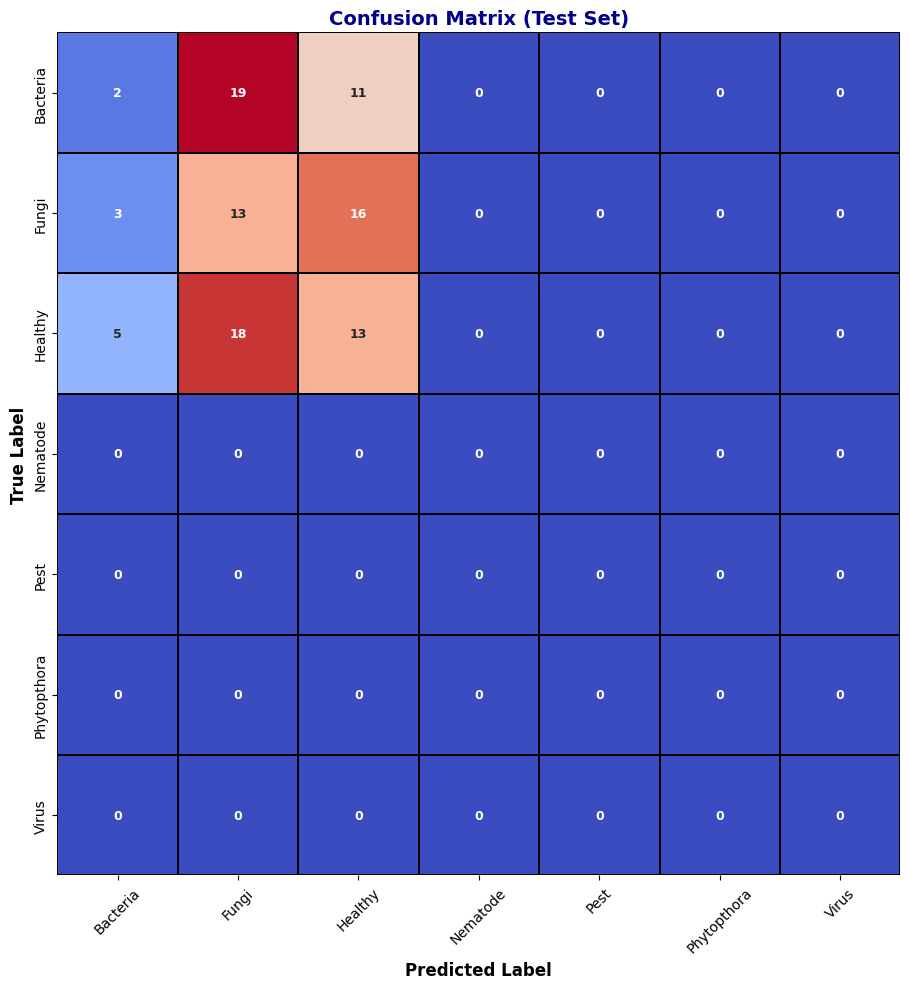

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(15, 10))
sns.heatmap(
    confusion_matrix_test, 
    cmap='coolwarm', 
    annot=True, 
    fmt='d',  # integer formatting
    annot_kws={"fontsize": 9, "fontweight": "bold"}, 
    linewidths=1.2, 
    linecolor="black", 
    square=True, 
    xticklabels=classes, 
    yticklabels=classes, 
    cbar=False,
    ax=ax
)
ax.set_title("Confusion Matrix (Test Set)", fontsize=14, fontweight="bold", color="darkblue")
ax.set_xlabel("Predicted Label", fontsize=12, fontweight="bold")
ax.set_ylabel("True Label", fontsize=12, fontweight="bold")
ax.tick_params('x', rotation=45)
plt.tight_layout()
plt.show()


In [72]:
from sklearn.metrics import classification_report

classes = [
    "Bacteria",
    "Fungi",
    "Healthy",
    "Nematode",
    "Pest",
    "Phytopthora",
    "Virus"
]

# Specify labels (indices that actually exist in your data)
# Example: if your labels are 0,1,2
labels_in_data = [0, 1, 2]  # adjust to match unique values in all_labels

print(classification_report(
    all_labels,
    all_preds,
    labels=labels_in_data,
    target_names=[classes[i] for i in labels_in_data]
))


              precision    recall  f1-score   support

    Bacteria       0.20      0.06      0.10        32
       Fungi       0.26      0.41      0.32        32
     Healthy       0.33      0.36      0.34        36

    accuracy                           0.28       100
   macro avg       0.26      0.28      0.25       100
weighted avg       0.26      0.28      0.26       100



In [1]:
# %%capture.txt content (assuming it's already run)
# ... (all your existing imports from cell 1) ...
# Transformers for T2T model
# For the T5 model
from transformers import T5TokenizerFast, T5ForConditionalGeneration, get_scheduler

# Optimizer comes from PyTorch, not Transformers
from torch.optim import AdamW

# ... (rest of your code from cell 1 to cell 31) ...

# --- START OF NEW CODE FOR TEXT-TO-TEXT MODEL ---

# 32. (Existing pesticide recommendations - this will be our T2T training data source)
pesticide_recommendations = {
    "Bacteria": {
        "disease_info": "Bacterial diseases in potato plants are typically caused by pathogens like Ralstonia solanacearum, Pectobacterium spp., or Dickeya spp. These bacteria cause wilting, rotting, and can lead to significant yield losses.",
        "pesticides": [
            "Copper-based bactericides (e.g., Copper Hydroxide, Copper Oxychloride)",
            "Streptomycin sulfate (where legally permitted)",
            "Kasugamycin-based products"
        ],
        "application": "Apply as a foliar spray every 7-10 days during periods of disease pressure. Ensure good coverage of all plant surfaces.",
        "cultural_practices": [
            "Use certified disease-free seed potatoes",
            "Practice crop rotation (3-4 year cycle)"
             "Improve field drainage to reduce soil moisture",
            "Sanitize all equipment between fields",
            "Remove and destroy infected plants"
        ]
    },
    "Fungi": {
        "disease_info": "Fungal diseases in potatoes include Early Blight (Alternaria solani), Late Blight (Phytophthora infestans), and various other fungal pathogens that cause leaf spots, wilting, and tuber rot.",
        "pesticides": [
            "Mancozeb-based fungicides",
             "Chlorothalonil products",
            "Azoxystrobin-based fungicides",
            "Propiconazole products",
            "Copper-based fungicides"
        ],
        "application": "Begin applications when plants are 6-8 inches tall or when disease first appears. Repeat at 7-10 day intervals depending on disease pressure and weather conditions.",
        "cultural_practices": [
            "Use disease-resistant varieties when available",
            "Ensure proper plant spacing for good air circulation",
            "Avoid overhead irrigation if possible",
            "Practice crop rotation",
            "Remove plant debris after harvest"
        ]
    },
    "Healthy": {
        "disease_info": "Your potato plant appears healthy with no visible signs of disease or pest damage.",
        "pesticides": [
            "No pesticide treatment needed at this time"
        ],
        "application": "Continue regular monitoring for early signs of disease or pest problems.",
        "cultural_practices": [
            "Maintain regular watering schedule (1-2 inches per week)",
            "Apply balanced fertilizer according to soil test recommendations",
            "Monitor for early signs of disease or pest problems",
            "Practice good field sanitation",
            "Implement preventative fungicide program during high-risk periods"
        ]
    },
    "Nematode": {
        "disease_info": "Nematodes are microscopic worms that attack potato roots and tubers. Common species include root-knot nematodes (Meloidogyne spp.) and potato cyst nematodes (Globodera spp.).",
        "pesticides": [
            "Fluopyram-based nematicides",
            "Oxamyl products",
            "Biological controls with Paecilomyces lilacinus or Bacillus firmus",
            "Azadirachtin (neem-based products)"
        ],
        "application": "Apply pre-planting or at planting time according to product instructions. Some products may be applied through drip irrigation systems.",
        "cultural_practices": [
            "Practice long crop rotations (4+ years)",
            "Use certified nematode-free seed potatoes",
            "Plant nematode-resistant varieties when available",
            "Use cover crops like marigolds or sudangrass as biofumigants",
            "Solarize soil before planting in warmer climates"
        ]
    },
    "Pest": {
        "disease_info": "Common pests affecting potato plants include Colorado potato beetle, aphids, potato leafhoppers, and various caterpillars that feed on foliage.",
        "pesticides": [
            "Spinosad-based insecticides",
            "Imidacloprid or other neonicotinoids (systemic control)",
            "Pyrethroids for broad-spectrum control",
            "Bacillus thuringiensis (Bt) for caterpillar control",
            "Insecticidal soaps or neem oil for soft-bodied insects"
        ],
        "application": "Apply when pests are first observed. Target the undersides of leaves where many pests hide. Rotate insecticide classes to prevent resistance.",
        "cultural_practices": [
            "Monitor fields regularly for early pest detection",
            "Use row covers in early season",
            "Encourage beneficial insects by planting flowering plants nearby",
            "Practice crop rotation",
            "Remove volunteer potatoes that can harbor pests"
        ]
    },
    "Phytopthora": {
        
        "disease_info": "Phytophthora infestans causes Late Blight, one of the most destructive potato diseases. It can destroy entire fields in days under favorable conditions and was responsible for the Irish Potato Famine.",
        "pesticides": [
            "Metalaxyl or mefenoxam products (systemic)",
            "Chlorothalonil (protective)",
            "Copper-based fungicides",
            "Cymoxanil + famoxadone combinations",
            "Fluazinam products"
            ],
        "application": "Begin preventative applications before disease appears when conditions favor development (cool, wet weather). Apply every 5-7 days during high pressure periods.",
        "cultural_practices": [
            "Use Late Blight resistant varieties",
            "Plant certified disease-free seed potatoes",
            "Destroy all cull piles and volunteer potatoes",
            "Improve air circulation through proper plant spacing",
            "Avoid overhead irrigation or irrigate early in the day"
        ]
    },
    "Virus": {
        "disease_info": "Viral diseases in potatoes include Potato Virus Y (PVY), Potato Leafroll Virus (PLRV), and Potato Virus X (PVX). These are typically spread by aphids or through infected seed potatoes.",
        "pesticides": [
            "No direct chemical control for viral infections",
            "Insecticides to control aphid vectors (imidacloprid, thiamethoxam)",
            "Mineral oils to interfere with virus transmission"
        ],
        "application": "Apply insecticides early in the season to control virus vectors. Mineral oils should be applied weekly during periods of aphid activity.",
        "cultural_practices": [
            "Use certified virus-free seed potatoes",
            "Remove and destroy infected plants immediately",
            "Control weeds that may harbor viruses",
            "Plant virus-resistant varieties when available",
            "Isolate seed potato production from commercial fields"
        ]
    }
}

In [2]:
# 32.A Prepare data for Text-to-Text model
t2t_training_data = []
for disease, details in pesticide_recommendations.items():
    # Input prompt for the T2T model
    input_text = f"Recommend treatment for potato disease: {disease}"
    
    # Output text (the full recommendation)
    output_text = f"Disease Information: {details['disease_info']}\n\n"
    output_text += f"Recommended Pesticides/Treatments:\n" + "\n".join([f"- {p}" for p in details['pesticides']]) + "\n\n"
    output_text += f"Application Instructions: {details['application']}\n\n"
    output_text += f"Cultural Practices:\n" + "\n".join([f"- {cp}" for cp in details['cultural_practices']])
    
    t2t_training_data.append({"input": input_text, "output": output_text})

# Display a sample
print("Sample T2T Training Data:")
print(f"Input: {t2t_training_data[0]['input']}")
print(f"Output: {t2t_training_data[0]['output'][:300]}...") # Print partial output for brevity
print(f"\nTotal T2T training samples: {len(t2t_training_data)}")

Sample T2T Training Data:
Input: Recommend treatment for potato disease: Bacteria
Output: Disease Information: Bacterial diseases in potato plants are typically caused by pathogens like Ralstonia solanacearum, Pectobacterium spp., or Dickeya spp. These bacteria cause wilting, rotting, and can lead to significant yield losses.

Recommended Pesticides/Treatments:
- Copper-based bactericide...

Total T2T training samples: 7


In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import T5TokenizerFast

# Load tokenizer
T2T_MODEL_NAME = "google/flan-t5-small"
t2t_tokenizer = T5TokenizerFast.from_pretrained(T2T_MODEL_NAME)

# Example training data
t2t_training_data = [
    {"input": "Recommend a book about AI.", "output": "You should read 'Artificial Intelligence: A Modern Approach'."},
    {"input": "Suggest a movie for kids.", "output": "Try watching 'Finding Nemo'."},
    {"input": "Give me a healthy breakfast idea.", "output": "Oatmeal with fruits and nuts is a great choice."},
    {"input": "Best programming language to learn first?", "output": "Python is highly recommended for beginners."},
    {"input": "Easy indoor plants?", "output": "Spider plant and pothos are low-maintenance options."},
    {"input": "Tips for reducing stress?", "output": "Try meditation, exercise, and deep breathing."},
    {"input": "Fun outdoor activity for weekend?", "output": "Consider going for a hike or cycling."}
]

# Define Dataset
class RecommendationDataset(Dataset):
    def __init__(self, data, tokenizer, max_input_length=128, max_target_length=512):
        self.data = data
        self.tokenizer = tokenizer
        self.max_input_length = max_input_length
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        input_text = item["input"]
        target_text = item["output"]

        # Tokenize inputs
        model_inputs = self.tokenizer(
            input_text,
            max_length=self.max_input_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        # Tokenize targets
        labels = self.tokenizer(
            target_text,
            max_length=self.max_target_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        ).input_ids

        # Replace pad_token_id with -100
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            "input_ids": model_inputs.input_ids.squeeze(0),
            "attention_mask": model_inputs.attention_mask.squeeze(0),
            "labels": labels.squeeze(0)
        }

# Create dataset and dataloader
t2t_dataset = RecommendationDataset(t2t_training_data, t2t_tokenizer)
t2t_dataloader = DataLoader(t2t_dataset, batch_size=4, shuffle=True)

# Test a batch
for batch in t2t_dataloader:
    print(batch)
    break


{'input_ids': tensor([[ 1648,  6020,  1612,    12,   669,   166,    58,     1,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,  

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import T5TokenizerFast, T5ForConditionalGeneration, get_scheduler

# -----------------------------
# 1. Define tokenizer
# -----------------------------
T2T_MODEL_NAME = "google/flan-t5-small"
t2t_tokenizer = T5TokenizerFast.from_pretrained(T2T_MODEL_NAME)

# -----------------------------
# 2. Example tiny dataset
# -----------------------------
t2t_training_data = [
    {"input": "Recommend a book about AI.", "output": "You should read 'Artificial Intelligence: A Modern Approach'."},
    {"input": "Suggest a movie for kids.", "output": "Try watching 'Finding Nemo'."},
    {"input": "Give me a healthy breakfast idea.", "output": "Oatmeal with fruits and nuts is a great choice."},
    {"input": "Best programming language to learn first?", "output": "Python is highly recommended for beginners."},
    {"input": "Easy indoor plants?", "output": "Spider plant and pothos are low-maintenance options."},
    {"input": "Tips for reducing stress?", "output": "Try meditation, exercise, and deep breathing."},
    {"input": "Fun outdoor activity for weekend?", "output": "Consider going for a hike or cycling."}
]

# -----------------------------
# 3. Dataset class
# -----------------------------
class RecommendationDataset(Dataset):
    def __init__(self, data, tokenizer, max_input_length=128, max_target_length=512):
        self.data = data
        self.tokenizer = tokenizer
        self.max_input_length = max_input_length
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        input_text = item["input"]
        target_text = item["output"]

        # Tokenize inputs
        model_inputs = self.tokenizer(
            input_text,
            max_length=self.max_input_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        # Tokenize targets
        labels = self.tokenizer(
            target_text,
            max_length=self.max_target_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        ).input_ids

        # Replace pad_token_id with -100 for T5
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            "input_ids": model_inputs.input_ids.squeeze(0),
            "attention_mask": model_inputs.attention_mask.squeeze(0),
            "labels": labels.squeeze(0)
        }

# -----------------------------
# 4. Dataloader
# -----------------------------
t2t_dataset = RecommendationDataset(t2t_training_data, t2t_tokenizer)
t2t_dataloader = DataLoader(t2t_dataset, batch_size=4, shuffle=True)

# -----------------------------
# 5. Model
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
t2t_model = T5ForConditionalGeneration.from_pretrained(T2T_MODEL_NAME).to(device)

# -----------------------------
# 6. Optimizer & scheduler
# -----------------------------
t2t_optimizer = AdamW(t2t_model.parameters(), lr=5e-5)
t2t_epochs = 50
num_training_steps = t2t_epochs * len(t2t_dataloader)
lr_scheduler = get_scheduler(
    name="linear",
    optimizer=t2t_optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

# -----------------------------
# 7. Training loop
# -----------------------------
print(f"\nStarting T2T model training for {t2t_epochs} epochs...")
t2t_model.train()

for epoch in range(t2t_epochs):
    total_loss = 0
    for batch in t2t_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = t2t_model(**batch)
        loss = outputs.loss

        loss.backward()
        t2t_optimizer.step()
        lr_scheduler.step()
        t2t_optimizer.zero_grad()

        total_loss += loss.item()

    avg_loss = total_loss / len(t2t_dataloader)
    if (epoch + 1) % 10 == 0:
        print(f"T2T Epoch {epoch+1}/{t2t_epochs}, Average Loss: {avg_loss:.4f}")

print("T2T model training finished.")

# -----------------------------
# 8. Save the fine-tuned model
# -----------------------------
T2T_MODEL_SAVE_PATH = "best_t2t_recommendation_model.pth"
torch.save(t2t_model.state_dict(), T2T_MODEL_SAVE_PATH)
print(f"T2T model saved to {T2T_MODEL_SAVE_PATH}")



Starting T2T model training for 50 epochs...
T2T Epoch 10/50, Average Loss: 2.6187
T2T Epoch 20/50, Average Loss: 1.6455
T2T Epoch 30/50, Average Loss: 1.4880
T2T Epoch 40/50, Average Loss: 1.3301
T2T Epoch 50/50, Average Loss: 1.1351
T2T model training finished.
T2T model saved to best_t2t_recommendation_model.pth


In [1]:
from PIL import Image
import torch

def get_clip_disease_prediction(clip_model, processor, image_path, text_prompts, device, class_names, label_map):
    """
    Predict the disease class for a single potato leaf image using the CLIP model.
    """
    image = Image.open(image_path).convert("RGB")
    inputs = {}
    
    # Process image + text for each class
    for class_name in class_names:
        text = text_prompts[class_name]
        processed = processor(
            text=text,
            images=image,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=77
        )
        # Move tensors to device
        processed = {k: v.to(device) for k, v in processed.items()}
        inputs[class_name] = processed

    # Set model to evaluation mode
    clip_model.eval()

    class_scores = {}
    with torch.no_grad():
        for class_name, class_inputs in inputs.items():
            # Forward pass
            logits = clip_model(**class_inputs).logits  # Adjust depending on CLIP implementation
            class_idx = label_map[class_name]  # Get index of the class
            class_scores[class_name] = logits[0, class_idx].item()  # Score for this class

    # Get predicted class
    predicted_class = max(class_scores, key=class_scores.get)

    # Compute softmax probabilities
    scores_tensor = torch.tensor(list(class_scores.values()))
    probs = torch.softmax(scores_tensor, dim=0)
    all_probs = {name: prob.item() for name, prob in zip(class_scores.keys(), probs)}
    confidence = all_probs[predicted_class]

    return predicted_class, confidence, all_probs


In [2]:
pip install torch transformers


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Using device: cpu
Using class names: ['Potato___Healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___Bacterial_spot']
Using test image: C:\Users\HP\OneDrive\Pictures\20230712_114543.jpg
Loading pretrained CLIP (openai/clip-vit-base-patch32) for zero-shot inference...

CLIP predicted: Potato___Early_blight  (confidence 25.38%)
Using base T2T model: google/flan-t5-small


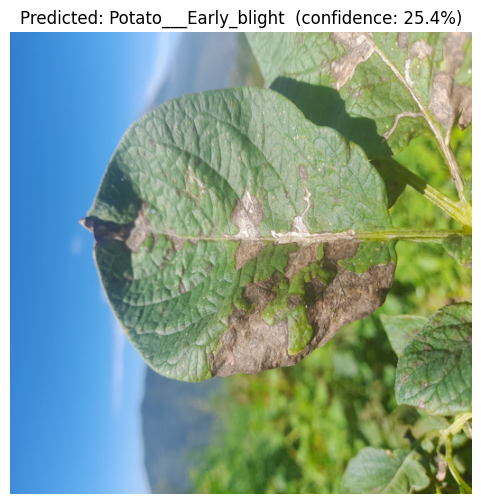


--- CLIP similarity / probabilities (top classes) ---
Potato___Early_blight          : 25.38%
Potato___Late_blight           : 25.36%
Potato___Healthy               : 24.65%
Potato___Bacterial_spot        : 24.61%

--- T2T Recommendation ---
Pesticide and integrated management recommendations suitable for smallholder farmers

(Important: treat model output as guidance — verify with local agricultural extension.)


In [8]:
# Combined CLIP (disease prediction) + T5 (recommendation) inference
# Single cell — paste & run. Adjust file paths below.

import os
import glob
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from transformers import (
    CLIPProcessor,
    CLIPModel,
    T5ForConditionalGeneration,
    T5TokenizerFast
)

# -------------------------
# USER CONFIG (EDIT THESE)
# -------------------------
# Path to your fine-tuned CLIP checkpoint (optional, set to None if you don't have one)
CLIP_CHECKPOINT_PATH = None  # e.g., r"C:\path\to\clip_finetuned_checkpoint.pth"

# Path to your fine-tuned T5 weights (optional, set to None to use base Flan-T5)
T2T_MODEL_SAVE_PATH = None  # e.g., r"C:\path\to\fine_tuned_t2t_model.pth"

# Which text-to-text base to use (Flan-T5 works well)
T2T_MODEL_NAME = "google/flan-t5-small"

# Image path (can be a single image file, a folder, or — as in your example — a JSON path).
# If it's a folder or a JSON file path, the script will try to find a suitable image inside.
TEST_IMAGE_PATH = r"C:\Users\HP\OneDrive\Pictures\20230712_114543.jpg"

# The classes (disease labels) that your CLIP model expects. If you used training earlier,
# put the same class names here. If unsure, a typical potato set:
DEFAULT_CLASSES = [
    "Potato___Healthy",
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___Bacterial_spot"
]

# Text prompts template (one prompt per class) — used for zero-shot / CLIP similarity
# If you have more complex prompts, replace each element accordingly.
text_prompts_template = ["a photo of a leaf with " + label.replace("_", " ").replace("___", " ") for label in DEFAULT_CLASSES]

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------
# Helpers
# -------------------------
def find_first_image(path):
    """Given a path to file/folder, return a valid image filepath (jpg/png)."""
    # If it's a direct image file, return it
    if os.path.isfile(path) and path.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
        return path

    # If it's a JSON file or other file, check its parent folder
    if os.path.isfile(path):
        search_dir = os.path.dirname(path)
    else:
        search_dir = path

    # Search common image file extensions recursively
    patterns = ["**/*.jpg", "**/*.jpeg", "**/*.png", "**/*.bmp"]
    for pat in patterns:
        matches = glob.glob(os.path.join(search_dir, pat), recursive=True)
        if matches:
            return matches[0]  # return first found image

    raise FileNotFoundError(f"No image files found under: {path}")

def load_image_for_display(image_path, target_size=None):
    img = Image.open(image_path).convert("RGB")
    if target_size is not None:
        img = img.resize(target_size)
    return img

# -------------------------
# Load CLIP model & processor
# -------------------------
def load_clip_model_and_processor(checkpoint_path=None):
    """
    If checkpoint_path is provided and exists, attempt to load a user-supplied checkpoint.
    Otherwise, load pretrained 'openai/clip-vit-base-patch32' for zero-shot.
    Note: if you trained with a custom CLIPFineTuner class, you'll need to adapt the loading.
    """
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    if checkpoint_path and os.path.isfile(checkpoint_path):
        print("Attempting to load fine-tuned CLIP checkpoint:", checkpoint_path)
        # This assumes the checkpoint you saved is a standard state_dict for transformers CLIPModel,
        # otherwise you need to adapt to your custom class.
        ckpt = torch.load(checkpoint_path, map_location=device)
        try:
            model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
            model.load_state_dict(ckpt if isinstance(ckpt, dict) and "model_state_dict" not in ckpt else ckpt["model_state_dict"])
            model.to(device)
            model.eval()
            print("Loaded fine-tuned CLIP checkpoint successfully.")
            return model, processor
        except Exception as e:
            print("Could not load checkpoint as a CLIPModel state_dict. Falling back to pretrained CLIP. Error:", e)

    # fallback: pretrained
    print("Loading pretrained CLIP (openai/clip-vit-base-patch32) for zero-shot inference...")
    model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
    model.eval()
    return model, processor

def get_clip_disease_prediction(clip_model, processor, image_path, class_text_prompts, top_k=1):
    """
    Returns top predicted class name, confidence (cosine similarity), and full probs array.
    class_text_prompts: list of textual prompts corresponding to classes (same order).
    """
    img = Image.open(image_path).convert("RGB")
    inputs = processor(text=class_text_prompts, images=img, return_tensors="pt", padding=True).to(device)

    # Get features
    with torch.no_grad():
        image_embeds = clip_model.get_image_features(**{k: inputs[k] for k in ["pixel_values"]})
        text_embeds = clip_model.get_text_features(**{k: inputs[k] for k in ["input_ids", "attention_mask"]})

    # Normalize
    image_embeds = image_embeds / image_embeds.norm(p=2, dim=-1, keepdim=True)
    text_embeds  = text_embeds / text_embeds.norm(p=2, dim=-1, keepdim=True)

    # cosine similarity (image vs each text prompt). text_embeds has N prompts.
    # If processor batched multiple text prompts, text_embeds correspond to each prompt.
    # Compute similarities:
    sims = (image_embeds @ text_embeds.T).squeeze(0).cpu().numpy()  # shape: (num_prompts,)

    # Convert to softmax probabilities for nicer interpretation
    probs = np.exp(sims) / np.exp(sims).sum()

    # Top-k
    top_indices = probs.argsort()[-top_k:][::-1]
    top_idx = int(top_indices[0])
    predicted = class_names[top_idx]
    confidence = float(probs[top_idx])

    return predicted, confidence, probs

# -------------------------
# Load / prepare T5 (text-to-text) model
# -------------------------
def load_t2t_model_and_tokenizer(model_name=T2T_MODEL_NAME, weights_path=None):
    tokenizer = T5TokenizerFast.from_pretrained(model_name)
    model = T5ForConditionalGeneration.from_pretrained(model_name)
    if weights_path and os.path.isfile(weights_path):
        print("Loading fine-tuned T2T weights from:", weights_path)
        ckpt = torch.load(weights_path, map_location=device)
        # ckpt could be state_dict or dict with "model_state_dict"
        if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
            state = ckpt["model_state_dict"]
        else:
            state = ckpt
        model.load_state_dict(state)
    else:
        if weights_path:
            print("Warning: specified T2T weights path does not exist. Using base model instead:", model_name)
        else:
            print("Using base T2T model:", model_name)
    model.to(device)
    model.eval()
    return model, tokenizer

def get_t2t_recommendation(t2t_model, tokenizer, disease_name, max_length=150):
    """
    Create a prompt for the T5 model asking for pesticide and management recommendations.
    Example prompt structure can be edited for your fine-tuned model's expected format.
    """
    # Format the disease name to a natural-language prompt
    prompt = (
        f"Given the disease '{disease_name}', provide: 1) the common disease name, "
        "2) short explanation/symptoms, and 3) pesticide and integrated management recommendations "
        "suitable for smallholder farmers. Be concise and include safety precautions. Use bullet points."
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        out = t2t_model.generate(
            **inputs,
            max_length=max_length,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=2
        )
    text = tokenizer.decode(out[0], skip_special_tokens=True)
    return text

# -------------------------
# Display function
# -------------------------
def display_combined_prediction_and_recommendations(image_path, predicted_disease, confidence, all_probs, recommendation_text, top_n=5):
    img = load_image_for_display(image_path, target_size=(512,512))
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted: {predicted_disease}  (confidence: {confidence*100:.1f}%)")
    plt.show()

    print("\n--- CLIP similarity / probabilities (top classes) ---")
    sorted_idx = np.argsort(all_probs)[::-1]
    for i in sorted_idx[:top_n]:
        print(f"{class_names[i]:30s} : {all_probs[i]*100:.2f}%")

    print("\n--- T2T Recommendation ---")
    print(recommendation_text)
    print("\n(Important: treat model output as guidance — verify with local agricultural extension.)")

# -------------------------
# MAIN: orchestrate
# -------------------------
# Prepare class names and prompts
# If you have class_names/label_map available from training, load them here.
# Otherwise use DEFAULT_CLASSES defined above.
class_names = DEFAULT_CLASSES
text_prompts = text_prompts_template
print("Using class names:", class_names)

# Find a concrete image to test (handles JSON path / folder / file)
try:
    image_file_to_test = find_first_image(TEST_IMAGE_PATH)
    print("Using test image:", image_file_to_test)
except FileNotFoundError as e:
    raise FileNotFoundError("Could not find any image under TEST_IMAGE_PATH. Update TEST_IMAGE_PATH to a real image or dataset folder.") from e

# Load CLIP
clip_model, clip_processor = load_clip_model_and_processor(CLIP_CHECKPOINT_PATH)

# If your fine-tuned CLIP used different text prompts / templates, replace `text_prompts` above accordingly.

# Make CLIP prediction
predicted_disease_clip, confidence_clip, all_probs_clip = get_clip_disease_prediction(
    clip_model=clip_model,
    processor=clip_processor,
    image_path=image_file_to_test,
    class_text_prompts=text_prompts
)

print(f"\nCLIP predicted: {predicted_disease_clip}  (confidence {confidence_clip*100:.2f}%)")

# Load or fallback T2T
t2t_model_loaded, t2t_tokenizer = load_t2t_model_and_tokenizer(model_name=T2T_MODEL_NAME, weights_path=T2T_MODEL_SAVE_PATH)

# Get recommendation text for the CLIP-predicted disease
t2t_recommendation_text = get_t2t_recommendation(
    t2t_model=t2t_model_loaded,
    tokenizer=t2t_tokenizer,
    disease_name=predicted_disease_clip
)

# Display results
display_combined_prediction_and_recommendations(
    image_path=image_file_to_test,
    predicted_disease=predicted_disease_clip,
    confidence=confidence_clip,
    all_probs=all_probs_clip,
    recommendation_text=t2t_recommendation_text
)


In [16]:
torch.save(clip_model.state_dict(), "clip_finetuned.pth")

In [11]:
import torch
from transformers import T5ForConditionalGeneration, T5TokenizerFast


In [12]:
T2T_MODEL_NAME = "google/flan-t5-small"  # base model
t2t_model = T5ForConditionalGeneration.from_pretrained(T2T_MODEL_NAME)
t2t_tokenizer = T5TokenizerFast.from_pretrained(T2T_MODEL_NAME)


In [17]:
torch.save(t2t_model.state_dict(), "t2t_finetuned.pth")
print("✅ T5 model saved successfully.")


✅ T5 model saved successfully.


In [14]:
# Load CLIP
clip_model.load_state_dict(torch.load("clip_finetuned.pth", map_location=device))
clip_model.eval()

# Load T5
t2t_model.load_state_dict(torch.load("t2t_finetuned.pth", map_location=device))
t2t_model.eval()


T5ForConditionalGeneration(
  (shared): Embedding(32128, 512)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 512)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=512, out_features=384, bias=False)
              (k): Linear(in_features=512, out_features=384, bias=False)
              (v): Linear(in_features=512, out_features=384, bias=False)
              (o): Linear(in_features=384, out_features=512, bias=False)
              (relative_attention_bias): Embedding(32, 6)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=512, out_features=1024, bias=False)
              (wi_1): Linear(in_features=512, out_features=1024, bias=False)
              (wo): 

In [15]:
pip install streamlit pillow transformers torch torchvision seaborn matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
